In [1]:
from typing import List, TypedDict
from langgraph.graph import StateGraph

In [2]:
class AgentState(TypedDict):
  name: str
  age: str
  final: str

In [4]:
def first_graph(state: AgentState)-> AgentState:
  """This is the first node of our sequential graph"""
  state['final']= f"Hii {state['name']}!"

  return state

def second_graph(state: AgentState)-> AgentState:
  """This is the second node of our sequential graph"""
  state['final']= state['final'] + f"You are {state['age']} years old."

  return state


In [8]:
graph= StateGraph(AgentState)
graph.add_node("first_graph", first_graph)
graph.add_node("second_graph", second_graph)

graph.set_entry_point("first_graph")
graph.add_edge("first_graph", "second_graph")
graph.set_finish_point("second_graph")

app= graph.compile()


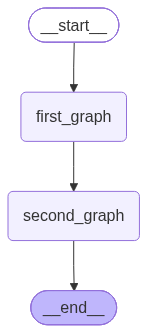

In [9]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
answer= app.invoke({"name": "Krityan", "age": "23"})

In [12]:
print(answer['final'])

Hii Krityan!You are 23 years old.
